# Exploration des données

### Importations des packages nécessaire

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Configuration de l'affichage des données avec pandas

In [3]:
pd.set_option('display.max_row', 891)
pd.set_option('display.max_column', 12)

### Importation du fichier contenant les données à traiter

In [4]:
data = pd.read_csv("data/titanic.csv")
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Traitement du dataset

In [5]:
# Connaitre la dimension de notre dataFrame
shape = data.shape
print(f"La dimension de notre dataset est de {shape} c'est-à dire {shape[0]} lignes et {shape[1]} colonnes");

La dimension de notre dataset est de (891, 12) c'est-à dire 891 lignes et 12 colonnes


<Axes: ylabel='count'>

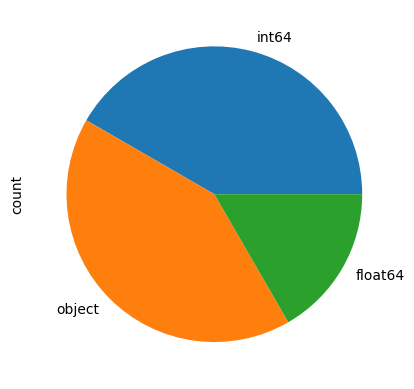

In [9]:
# Connaitre tous les types de nos données
data.dtypes.value_counts().plot.pie()

<Axes: >

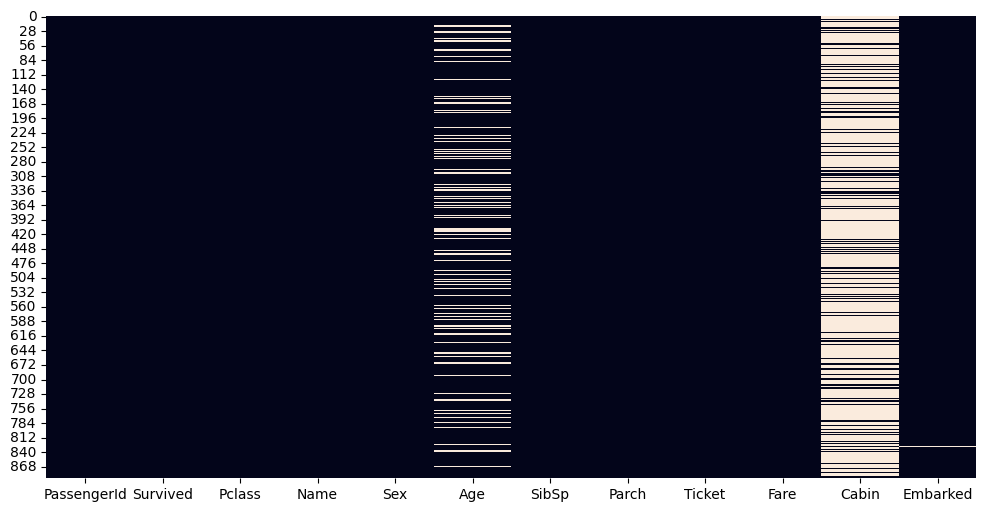

In [10]:
# Savoir tout les valeurs manquantes du dataset
plt.figure(figsize=(12, 6))
sns.heatmap(data.isna(), cbar=False)

In [11]:
# Effectuer la pourcentage des valeurs manquantes
(data.isna().sum() / data.shape[0]).sort_values(ascending=True)

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Embarked       0.002245
Age            0.198653
Cabin          0.771044
dtype: float64

In [12]:
# Elimination des variable inutiles
data = data.drop(["PassengerId", "Parch", "Ticket", "Cabin"], axis=1)
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,8.0500,S


### Statistics

In [13]:
# Statistique globale
data = data.dropna(axis=0)
data.describe()

,Survived,Pclass,Age,SibSp,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.404494,2.240169,29.642093,0.514045,34.567251
std,0.491139,0.836854,14.492933,0.930692,52.938648
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,15.645850
75%,1.000000,3.000000,38.000000,1.000000,33.000000
max,1.000000,3.000000,80.000000,5.000000,512.329200


<Axes: xlabel='count', ylabel='Count'>

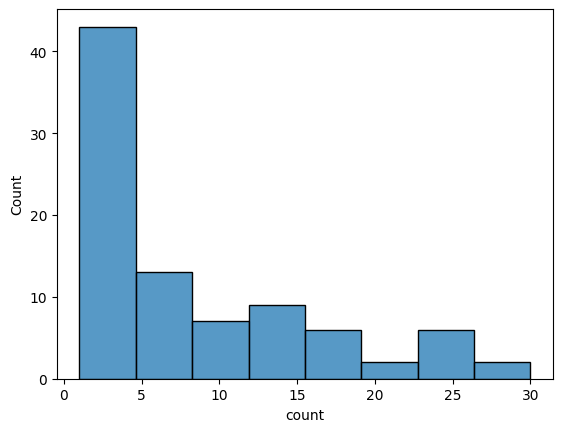

In [14]:
# L'age des passagers
sns.histplot(data["Age"].value_counts())

Sur 712, seulement 288 passagers ont survécus! (424 passagers sont morts)


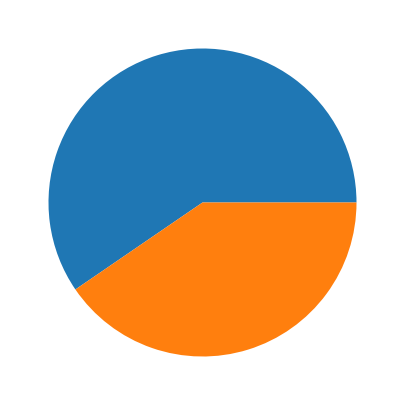

In [15]:
# Nombre de passagers morte lors du naufrage du navire
surv = data["Survived"].value_counts()
print(f"Sur {data.shape[0]}, seulement {surv[1]} passagers ont survécus! ({surv[0]} passagers sont morts)")
plt.figure(figsize=(5, 5))
plt.pie(surv)
plt.show()

In [16]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,8.0500,S


In [17]:
# Transformation des variables catégorielles (exemple : 'Sex' et 'Embarked')
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

In [18]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,53.1000,2
4,0,3,"Allen, Mr. William Henry",0,35.0,0,8.0500,2


### Creation d'une nouvelle dataset pour l'analyse

In [19]:
# data.to_excel("data/filtered_data.xlsx")